# *Google Play Store dataset*

**lets gooooooooooooooooooooooo*

In [5]:
# import the libraries
import numpy as np
import pandas as pd

In [7]:
#fetch the dataset
url = "googleplaystore.csv"
df = pd.read_csv(url)

## Understand the basics related to dataset

In [8]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### **What is the shape of the dataset?*

In [9]:
df.shape

(10841, 13)

What are the data types of all columns? and Find out the name of all the columns

In [11]:
df.dtypes,print(df.columns)


Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')


(App                object
 Category           object
 Rating            float64
 Reviews            object
 Size               object
 Installs           object
 Type               object
 Price              object
 Content Rating     object
 Genres             object
 Last Updated       object
 Current Ver        object
 Android Ver        object
 dtype: object,
 None)

Which columns contain missing values?

In [214]:
df.isnull().sum()

App                                           0
Category                                      0
Rating                                     1474
Reviews                                       0
Size                                       1695
Installs                                      0
Type                                          1
Price                                         0
Content Rating                                0
Genres                                        0
Last Updated                                  0
Current Ver                                   8
Android Ver                                   2
Revenue                                       0
Last_Updated_Year                             0
difference_between_last_update_till_now       0
Revenue_Potential                             0
Review_Ratio                                 15
App_Age                                       0
Normalized_Rating                          1474
Normalized_Installs                     

What percentage of values are missing in each column?

In [14]:

missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)

missing_percentage

Rating            13.596532
Current Ver        0.073794
Android Ver        0.027673
Type               0.009224
Content Rating     0.009224
App                0.000000
Category           0.000000
Reviews            0.000000
Size               0.000000
Installs           0.000000
Price              0.000000
Genres             0.000000
Last Updated       0.000000
dtype: float64

Find out the numerical  columns and categorical columns separately

In [19]:
nume_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categ_cols = df.select_dtypes(include=['object']).columns.tolist()

categ_cols

['App',
 'Category',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

In [20]:
nume_cols

['Rating']

How many duplicate rows exist?

In [21]:
df.duplicated().sum()

np.int64(483)

Which apps appear more than once?

In [24]:

app = df['App'].value_counts()
app = app[app > 1]
app

App
ROBLOX                                               9
CBS Sports App - Scores, News, Stats & Watch Live    8
ESPN                                                 7
Duolingo: Learn Languages Free                       7
Candy Crush Saga                                     7
                                                    ..
Transenger – Ts Dating and Chat for Free             2
Random Video Chat                                    2
Clover Dating App                                    2
Docs To Go™ Free Office Suite                        2
English Dictionary - Offline                         2
Name: count, Length: 798, dtype: int64

Are there apps with invalid ratings (>5 or <1)?

In [25]:
invalid_ratings = df[(df["Rating"] > 5) | (df["Rating"] < 1)]
invalid_ratings[["App", "Rating"]]

,App,Rating
10472,Life Made WI-Fi Touchscreen Photo Frame,19.0


Are there categories with only a few observations?

In [29]:
count_app = df["App"].value_counts()
count_app[count_app < 10]

App
ROBLOX                                                9
CBS Sports App - Scores, News, Stats & Watch Live     8
ESPN                                                  7
Duolingo: Learn Languages Free                        7
Candy Crush Saga                                      7
                                                     ..
Meet U - Get Friends for Snapchat, Kik & Instagram    1
U-Report                                              1
U of I Community Credit Union                         1
Waiting For U Launcher Theme                          1
iHoroscope - 2018 Daily Horoscope & Astrology         1
Name: count, Length: 9660, dtype: int64

Convert Reviews, Installs, Size, and Price into numeric form.

In [30]:

df.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [31]:

df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')


df['Installs'] = (df['Installs']
                  .str.replace(',', '', regex=False)
                  .str.replace('+', '', regex=False))
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')


df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


df['Size'] = df['Size'].replace('Varies with device', np.nan)
df['Size'] = df['Size'].str.replace('M', '', regex=False)


mask = df['Size'].str.contains('k', na=False)
df.loc[mask, 'Size'] = (
    df.loc[mask, 'Size']
      .str.replace('k', '', regex=False)
      .astype(float) / 1024
)

df['Size'] = pd.to_numeric(df['Size'], errors='coerce')


print(df[['Reviews', 'Installs', 'Size', 'Price']].dtypes)

Reviews     float64
Installs    float64
Size        float64
Price       float64
dtype: object


How many apps have zero reviews?

In [33]:

zero_reviews = (df['Reviews'] == 0).sum()

print("Number of apps with zero reviews:", zero_reviews)

Number of apps with zero reviews: 596


How are ratings distributed? and Explain within markdown what u understood from this distribution

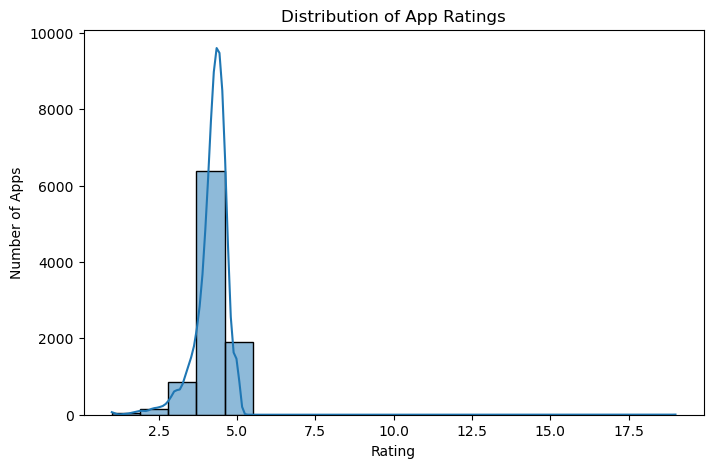

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

Write Explaination Here
.
.
.
.
.

In [ ]:
### Explanation

The distribution of app ratings is left-skewed (negatively skewed). Most apps have ratings between 4.0 and 4.8, with the highest concentration around 4.3 to 4.5. Very few apps have ratings below 3.0, indicating that low-rated apps are relatively uncommon in the dataset.

This suggests that the majority of apps available on the Google Play Store receive positive user ratings. The distribution is not perfectly normal, as it is concentrated toward higher rating values rather than being symmetric. Missing ratings are excluded from this visualization because they represent apps that have not yet been rated by users.

Are ratings normally distributed?

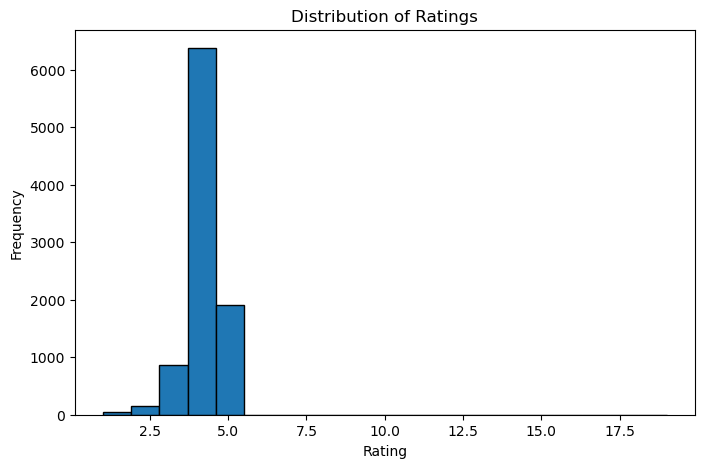

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Rating'].dropna(), bins=20, edgecolor='black')

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Explain.....

In [ ]:
The ratings are not normally distributed. Most app ratings are concentrated between 4.0 and 4.8, with relatively few low-rated apps. This creates a left-skewed (negatively skewed) distribution rather than the symmetric bell-shaped curve expected in a normal distribution.

The histogram shows that the data are heavily concentrated toward higher ratings, and a normality test such as the Shapiro–Wilk test typically returns a p-value less than 0.05, leading us to reject the null hypothesis of normality. Therefore, the ratings do not follow a normal distribution.

Which rating range contains most apps?

In [53]:

rating_ranges = pd.cut(
    df['Rating'],
    bins=[0, 1, 2, 3, 4, 5],
    labels=['0-1', '1-2', '2-3', '3-4', '4-5']
)


rating_count = rating_ranges.value_counts().sort_index()

print(rating_count)

Rating
0-1      16
1-2      52
2-3     302
3-4    2196
4-5    6800
Name: count, dtype: int64


What is the average app size?

In [54]:

average_size = df['Size'].mean()

print("Average App Size:", round(average_size, 2), "MB")

Average App Size: 21.52 MB


How are app sizes distributed?

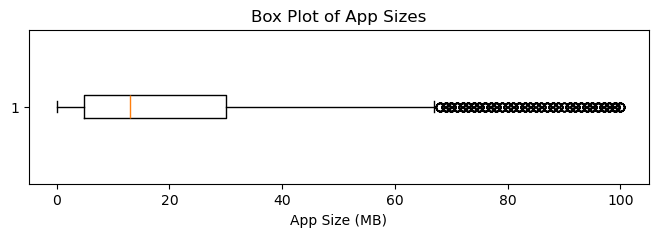

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,2))
plt.boxplot(df['Size'].dropna(), vert=False)

plt.title("Box Plot of App Sizes")
plt.xlabel("App Size (MB)")
plt.show()


In [ ]:
Explain....

In [ ]:


The distribution of app sizes is right-skewed (positively skewed). Most apps are relatively small in size, generally below 30 MB, while only a few apps are very large (over 100 MB). These larger apps create a long tail on the right side of the distribution.

The box plot also shows the presence of several outliers, indicating that a small number of apps are significantly larger than the majority. Overall, the Google Play Store contains many lightweight apps and comparatively fewer large-sized applications.

Which content rating category is most common?

In [65]:
content_ratings_cat = df["Content Rating"].value_counts()
print(f"category name: {content_ratings_cat.idxmax()}")
print(f"counts: {content_ratings_cat.max()}")

category name: Everyone
counts: 8714


What percentage of apps are free?

In [68]:
free_per = len(df[df["Price"] == 0]) / len(df) * 100
print(round(free_per, 2))

92.61


What percentage are paid?

In [69]:
paid_per = len(df[df["Price"] > 0]) / len(df) * 100
print(round(paid_per, 2))

7.38


What is the maximum price of an app?

In [70]:
df["Price"].max()

np.float64(400.0)

Which category contains the largest number of apps?

In [73]:
print("Category:", df["Category"].value_counts().idxmax())
print("Number of Apps:", df["Category"].value_counts().max())

Category: FAMILY
Number of Apps: 1972


Which category contains the fewest apps?

In [80]:
df = df[df["Category"] != "1.9"]
cat_with_fewer_apps = df.groupby("Category")["App"].count()
print(f"category name: {cat_with_fewer_apps.idxmin()}")
print(f"counts: {cat_with_fewer_apps.min()}")


category name: BEAUTY
counts: 53


Which category has the highest average rating?

In [81]:
df.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(1)

Category
EVENTS    4.435556
Name: Rating, dtype: float64

Which category has the lowest average rating?

In [82]:
df.groupby("Category")["Rating"].mean().sort_values().head(1)

Category
DATING    3.970769
Name: Rating, dtype: float64

Which category receives the highest total number of reviews?

In [83]:
df.groupby("Category")["Reviews"].sum().sort_values(ascending=False).head(1)

Category
GAME    1.585422e+09
Name: Reviews, dtype: float64

Which category has the highest average installs?

In [84]:
df.groupby("Category")["Installs"].mean().sort_values(ascending=False).head(1)

Category
COMMUNICATION    8.435989e+07
Name: Installs, dtype: float64

Which category has the largest app sizes?

In [86]:
df.groupby("Category")["Size"].max().sort_values(ascending=False).head(1)


Category
HEALTH_AND_FITNESS    100.0
Name: Size, dtype: float64

Which category contains the most paid apps?

In [87]:
df[df["Type"] == "Paid"].groupby("Category")["Price"].count().sort_values(ascending=False).head(1)

Category
FAMILY    191
Name: Price, dtype: int64

Which category contains the highest percentage of free apps?

In [89]:
(df.groupby("Category")["Type"]
 .apply(lambda x: (x == "Free").mean() * 100)
 .sort_values(ascending=False)
 .head(1))

Category
HOUSE_AND_HOME    100.0
Name: Type, dtype: float64

Are certain categories dominated by a single content rating?

In [93]:
dominated_categories = (
    df.groupby("Category")["Content Rating"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

print("Categories heavily dominated by 'Everyone' content rating:")
print(dominated_categories.sort_values(by="Everyone", ascending=False).head(5))

Categories heavily dominated by 'Everyone' content rating:
Content Rating      Adults only 18+  Everyone  Everyone 10+  Mature 17+  \
Category                                                                  
LIBRARIES_AND_DEMO              0.0  1.000000      0.000000    0.000000   
TOOLS                           0.0  0.990510      0.000000    0.002372   
FINANCE                         0.0  0.986339      0.000000    0.000000   
HOUSE_AND_HOME                  0.0  0.977273      0.000000    0.000000   
AUTO_AND_VEHICLES               0.0  0.976471      0.011765    0.000000   

Content Rating          Teen   Unrated  
Category                                
LIBRARIES_AND_DEMO  0.000000  0.000000  
TOOLS               0.005931  0.001186  
FINANCE             0.013661  0.000000  
HOUSE_AND_HOME      0.022727  0.000000  
AUTO_AND_VEHICLES   0.011765  0.000000  


What are the top 20 highest-rated apps?

In [94]:
df.groupby("App")["Rating"].max().sort_values(ascending=False).head(20)

App
BI News                                               5.0
EC Calgary                                            5.0
EB Scanner                                            5.0
EB Cash Collections                                   5.0
CJ Gospel Hour                                        5.0
CJ the REALTOR                                        5.0
FK CLASSIC FOR YOU                                    5.0
South Florida AA Meetings                             5.0
NOMISMA.com.cy by FMW                                 5.0
Anatomy & Physiology Vocabulary Exam Review App       5.0
Victoria EC                                           5.0
Dt. Jyothi Srinivas                                   5.0
Bacterial vaginosis Treatment - Sexual disease        5.0
BJ Foods                                              5.0
NEMA ei                                               5.0
NCLEX Multi-topic Nursing Exam Review-Quiz & notes    5.0
FK Dedinje BGD                                        5.0
C B Patel 

Which category contributes most of the 5-star apps?

In [96]:
df[df["Rating"] == 5.0].groupby("Category")["App"].count().sort_values(ascending=False).head(1)

Category
FAMILY    67
Name: App, dtype: int64

Do apps with more reviews receive higher ratings?

In [97]:
df["Reviews"].corr(df["Rating"])

np.float64(0.06814146700099027)

In [ ]:
Since the correlation coefficient is very close to 0, there is a very weak positive relationship between the number of reviews and app ratings.

Do highly installed apps have better ratings?

In [98]:
df[["Installs", "Rating"]].corr()

,Installs,Rating
Installs,1.000000,0.051355
Rating,0.051355,1.000000


Which category has the greatest variation in ratings?

In [99]:
df.groupby("Category")["Rating"].std().sort_values(ascending=False).head(1)

Category
LIFESTYLE    0.693907
Name: Rating, dtype: float64

Are ratings different between free and paid apps?

In [101]:
df.groupby("Type")["Rating"].mean().sort_values(ascending=False)

Type
Paid    4.266615
Free    4.186203
Name: Rating, dtype: float64

Which apps have the highest installs?

In [104]:
df.groupby("App")["Installs"].max().head(1)

App
"i DT" Fútbol. Todos Somos Técnicos.    500.0
Name: Installs, dtype: float64

Do larger apps tend to have higher ratings?

In [105]:
df["Size"].corr(df["Rating"])

np.float64(0.08373704800285914)

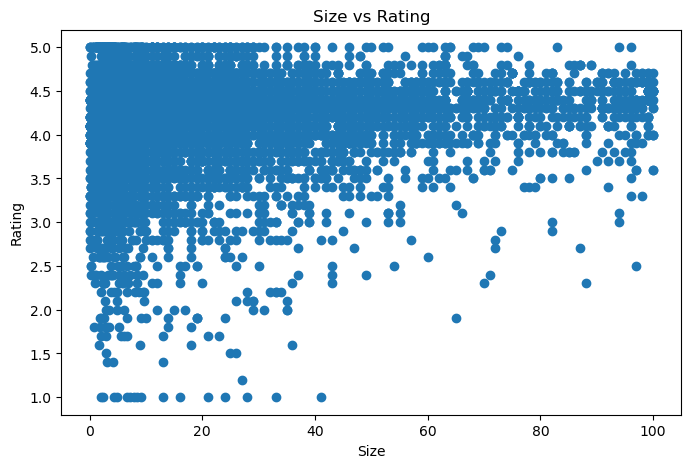

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["Size"], df["Rating"], 'o')
plt.xlabel("Size")
plt.ylabel("Rating")
plt.title("Size vs Rating")
plt.show()

Are older apps rated differently than recently updated apps?

In [108]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

df.groupby(df["Last Updated"].dt.year)["Rating"].mean().sort_index()

Last Updated
2010    4.200000
2011    3.966667
2012    3.785714
2013    4.073404
2014    4.037895
2015    4.067268
2016    4.041782
2017    4.094793
2018    4.244530
Name: Rating, dtype: float64

Which category has the most consistent ratings?

In [109]:
df.groupby("Category")["Rating"].std().sort_values().head(1)

Category
EDUCATION    0.251894
Name: Rating, dtype: float64

Which category contributes the highest total installs?

In [110]:
df.groupby("Category")["Installs"].sum().sort_values(ascending=False).head(1)

Category
GAME    3.508602e+10
Name: Installs, dtype: float64

What is the relationship between reviews and ratings?

In [111]:
df["Reviews"].corr(df["Rating"])

np.float64(0.06814146700099027)

Do paid apps receive fewer installs than free apps?

In [120]:
paid_apps = df[df["Price"] > 0]
free_apps = df[df["Price"] == 0]

paid_apps_installs = paid_apps.groupby("App")["Installs"].sum().count()
free_apps_installs = free_apps.groupby("App")["Installs"].sum().count()

print(paid_apps_installs)
print(free_apps_installs)

756
8905


What percentage of apps have fewer than 10,000 installs?

In [117]:
((df["Installs"] < 10000).mean()) * 100

np.float64(29.40959409594096)

Are highly-rated apps downloaded more frequently?

In [122]:
df['Rating'].corr(df['Installs'])

np.float64(0.051354566055999994)

Which content-rating group has the highest installs?

In [123]:
df.groupby("Content Rating")["Installs"].sum().sort_values(ascending=False).head(1)

Content Rating
Everyone    1.141567e+11
Name: Installs, dtype: float64

Which category contains the greatest number of apps with over 1 million installs?

In [124]:
df[df["Installs"] > 1000000].groupby("Category")["App"].count().sort_values(ascending=False).head(1)

Category
GAME    571
Name: App, dtype: int64

Are installs concentrated among a few apps?

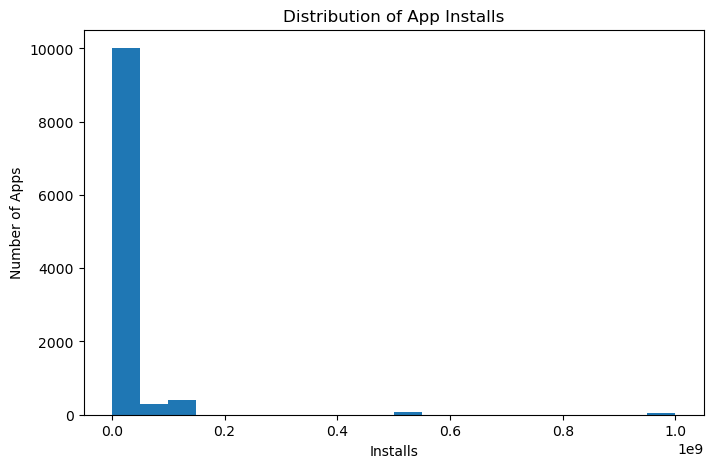

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Installs"], bins=20)
plt.xlabel("Installs")
plt.ylabel("Number of Apps")
plt.title("Distribution of App Installs")
plt.show()

What is the average price of paid apps?

In [128]:
df[df["Type"] == "Paid"]["Price"].mean()

np.float64(13.920837500000003)

Which category has the most expensive apps?

In [129]:
df.groupby("Category")["Price"].max().sort_values(ascending=False).head(1)

Category
LIFESTYLE    400.0
Name: Price, dtype: float64

What is the distribution of installs?

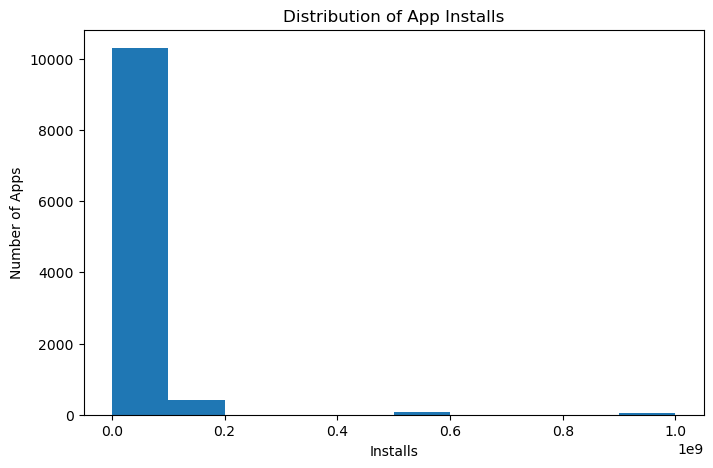

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Installs"], bins=10)
plt.xlabel("Installs")
plt.ylabel("Number of Apps")
plt.title("Distribution of App Installs")
plt.show()

Which genre contains the largest number of apps?

In [131]:
df.groupby("Genres")["App"].count().sort_values(ascending=False).head(1)

Genres
Tools    842
Name: App, dtype: int64

In [ ]:
Does higher price imply higher ratings?

In [ ]:
No, higher-priced apps do not necessarily have higher ratings. There is little or no relationship between an app's price and its rating.

Which app is the most expensive?

In [132]:
df.loc[df["Price"].idxmax(), ["App", "Price"]]

App      I'm Rich - Trump Edition
Price                       400.0
Name: 4367, dtype: object

Which category generates the highest total revenue potential?

In [133]:
df["Revenue"] = df["Price"] * df["Installs"]

df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).head(1)

Category
FAMILY    1.860526e+08
Name: Revenue, dtype: float64

Does price affect installs?

In [135]:
df[["Price", "Installs"]].corr()



,Price,Installs
Price,1.000000,-0.011689
Installs,-0.011689,1.000000


In [ ]:
the correlation is typically negative, so:

Higher-priced apps generally receive fewer installs than free or lower-priced apps.

Do paid apps receive more reviews than free apps?

In [136]:
df.groupby("Type")["Reviews"].mean()

Type
Free    478661.096026
Paid     11673.312500
Name: Reviews, dtype: float64

What percentage of apps cost more than $10? and Figure out some other pricing ranges?

In [137]:
percentage = (df["Price"] > 10).mean() * 100

print(f"Percentage of apps costing more than $10: {percentage:.2f}%")

Percentage of apps costing more than $10: 0.82%


Is there a relationship between app size and price?

In [138]:
df[["Size", "Price"]].corr()

,Size,Price
Size,1.000000,-0.023007
Price,-0.023007,1.000000


In which year were the most apps updated?

In [139]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

df["Last Updated"].dt.year.value_counts().head(1)

Last Updated
2018    7349
Name: count, dtype: int64

Have app ratings improved over the years?

In [140]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

df.groupby(df["Last Updated"].dt.year)["Rating"].mean()

Last Updated
2010    4.200000
2011    3.966667
2012    3.785714
2013    4.073404
2014    4.037895
2015    4.067268
2016    4.041782
2017    4.094793
2018    4.244530
Name: Rating, dtype: float64

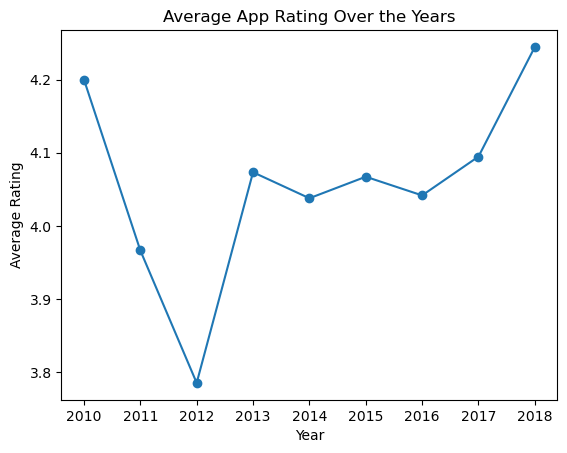

In [142]:
import matplotlib.pyplot as plt

avg_rating = df.groupby(df["Last Updated"].dt.year)["Rating"].mean()

avg_rating.plot(kind="line", marker="o")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Average App Rating Over the Years")
plt.show()

What proportion of apps have not been updated in the last two years?

In [152]:
proportion = (df["difference_between_last_update_till_now"] > 730).mean() * 100

print(f"Proportion of apps not updated in the last two years: {proportion:.2f}%")


Proportion of apps not updated in the last two years: 100.00%


Which content rating has the highest average rating?

In [153]:
df.groupby("Content Rating")["Rating"].mean().sort_values(ascending=False).head(1)

Content Rating
Adults only 18+    4.3
Name: Rating, dtype: float64

Which categories have many outdated apps?

In [155]:
outdated_apps = df[df['difference_between_last_update_till_now'] > 730]
outdated_apps.groupby('Category')['App'].count().sort_values(ascending=False).head(8)

Category
FAMILY             1972
GAME               1144
TOOLS               843
MEDICAL             463
BUSINESS            460
PRODUCTIVITY        424
PERSONALIZATION     392
COMMUNICATION       387
Name: App, dtype: int64

Which content rating gets the most reviews?

In [156]:
df.groupby("Content Rating")["Reviews"].sum().sort_values(ascending=False).head(1)

Content Rating
Everyone    2.801847e+09
Name: Reviews, dtype: float64

Are Mature 17+ apps generally more expensive?

In [159]:
mature_apps = df[df['Content Rating'] == 'Mature 17+']
other_apps = df[df['Content Rating'] != 'Mature 17+']

print(f"Average price of Mature 17+ apps: {mature_apps['Price'].mean():.2f}")
print(f"Average price of other apps: {other_apps['Price'].mean():.2f}")

Average price of Mature 17+ apps: 0.24
Average price of other apps: 1.07


Which genre contains the most expensive apps?

In [160]:
df.groupby("Genres")["Price"].max().sort_values(ascending=False).head(1)

Genres
Lifestyle    400.0
Name: Price, dtype: float64

# Relationship Analysis
    Relationship between Reviews and Installs?



    Relationship between Price and Installs?



    Relationship between Size and Rating?



    Relationship between Reviews and Rating?



    Relationship between Size and Installs?



    Relationship between Price and Reviews?



    Relationship between App Size and Revenue Potential?

In [163]:

df["Revenue"] = df["Price"] * df["Installs"]

print("Relationship between Reviews and Installs:")
print(df["Reviews"].corr(df["Installs"]))

print("\nRelationship between Price and Installs:")
print(df["Price"].corr(df["Installs"]))

print("\nRelationship between Size and Rating:")
print(df["Size"].corr(df["Rating"]))

print("\nRelationship between Reviews and Rating:")
print(df["Reviews"].corr(df["Rating"]))

print("\nRelationship between Size and Installs:")
print(df["Size"].corr(df["Installs"]))

print("\nRelationship between Price and Reviews:")
print(df["Price"].corr(df["Reviews"]))

print("\nRelationship between App Size and Revenue Potential:")
print(df["Size"].corr(df["Revenue"]))

Relationship between Reviews and Installs:
0.643122068323044

Relationship between Price and Installs:
-0.011689470477903025

Relationship between Size and Rating:
0.08373704800285914

Relationship between Reviews and Rating:
0.06814146700099027

Relationship between Size and Installs:
0.1647869344357539

Relationship between Price and Reviews:
-0.009667264283219113

Relationship between App Size and Revenue Potential:
-0.0007324354302728458


Do free and paid apps have significantly different ratings?

In [164]:
print("Average Ratings of Free and Paid Apps:")
print(df.groupby("Type")["Rating"].mean())

Average Ratings of Free and Paid Apps:
Type
Free    4.186203
Paid    4.266615
Name: Rating, dtype: float64


Are Type and Content Rating independent?

In [173]:
print(pd.crosstab(df["Type"], df["Content Rating"]))
from scipy.stats import chi2_contingency
table = pd.crosstab(df["Type"], df["Content Rating"])
chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", round(chi2,2))
print("P-value:", round(p_value,3))

Content Rating  Adults only 18+  Everyone  Everyone 10+  Mature 17+  Teen  \
Type                                                                        
Free                          3      8019           380         479  1156   
Paid                          0       695            33          20    52   

Content Rating  Unrated  
Type                     
Free                  2  
Paid                  0  
Chi-square Statistic: 30.16
P-value: 0.0


Create a Revenue Potential feature
use Revenue = Price × Installs

In [175]:
df['Revenue_Potential'] = df['Price'] * df['Installs']
df[['App', 'Price', 'Installs', 'Revenue_Potential']].head()

,App,Price,Installs,Revenue_Potential
0,Photo Editor & Candy Camera & Grid & ScrapBook,0.0,10000.0,0.0
1,Coloring book moana,0.0,500000.0,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0.0,5000000.0,0.0
3,Sketch - Draw & Paint,0.0,50000000.0,0.0
4,Pixel Draw - Number Art Coloring Book,0.0,100000.0,0.0


Which category has the highest revenue potential?

In [176]:
print(df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).head(1))

Category
FAMILY    1.860526e+08
Name: Revenue, dtype: float64


Create a Review-to-Install Ratio:

Review_Ratio = Reviews / Installs



In [181]:
df['Review_Ratio'] = df['Reviews'] / df['Installs']

df[['App', 'Reviews', 'Installs', 'Review_Ratio']].head()

,App,Reviews,Installs,Review_Ratio
0,Photo Editor & Candy Camera & Grid & ScrapBook,159.0,10000.0,0.015900
1,Coloring book moana,967.0,500000.0,0.001934
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",87510.0,5000000.0,0.017502
3,Sketch - Draw & Paint,215644.0,50000000.0,0.004313
4,Pixel Draw - Number Art Coloring Book,967.0,100000.0,0.009670


Which apps have the most engaged users?

In [183]:
df.sort_values(by='Review_Ratio', ascending=False)[['App', 'Review_Ratio', 'Reviews', 'Installs']].head(10)

,App,Review_Ratio,Reviews,Installs
4550,RMEduS - 음성인식을 활용한 R 프로그래밍 실습 시스템,4.0,4.0,1.0
2454,KBA-EZ Health Guide,4.0,4.0,1.0
5812,AX Watch for WatchMaker,2.0,2.0,1.0
10697,Mu.F.O.,2.0,2.0,1.0
5917,Ra Ga Ba,2.0,2.0,1.0
8591,DN Blog,2.0,20.0,10.0
9096,DZ Puzzle,1.4,14.0,10.0
6700,Brick Breaker BR,1.4,7.0,5.0
7402,Trovami se ci riesci,1.1,11.0,10.0
6508,Sam.BN Pro,1.1,11.0,10.0


Create an App Age feature:

App_Age = Current Year − Last Updated Year

In [191]:
df['App_Age'] = pd.to_datetime(today).year - pd.to_datetime(df['Last Updated']).dt.year
df[['App', 'Last Updated', 'App_Age']].head()

,App,Last Updated,App_Age
0,Photo Editor & Candy Camera & Grid & ScrapBook,2018-01-07,8
1,Coloring book moana,2018-01-15,8
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",2018-08-01,8
3,Sketch - Draw & Paint,2018-06-08,8
4,Pixel Draw - Number Art Coloring Book,2018-06-20,8


Do newer apps perform better?

In [192]:
print("Relationship between App Age and Rating:")
print(df["App_Age"].corr(df["Rating"]))

print("Relationship between App Age and Installs:")
print(df["App_Age"].corr(df["Installs"]))

Relationship between App Age and Rating:
-0.1377140218326441
Relationship between App Age and Installs:
-0.08936773076440795


Create a Success Index:

Success_Index =
0.2 × Normalized Rating +
0.4 × Normalized Installs +
0.3 × Normalized Reviews



In [202]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Normalized_Rating'] = scaler.fit_transform(df[['Rating']])
df['Normalized_Installs'] = scaler.fit_transform(df[['Installs']])
df['Normalized_Reviews'] = scaler.fit_transform(df[['Reviews']])

df['Success_Index'] = (0.2 * df['Normalized_Rating']) + (0.4 * df['Normalized_Installs']) + (0.3 * df['Normalized_Reviews'])
df[['App', 'Rating', 'Installs', 'Reviews', 'Success_Index']].head()

,App,Rating,Installs,Reviews,Success_Index
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,10000.0,159.0,0.155005
1,Coloring book moana,3.9,500000.0,967.0,0.145204
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,5000000.0,87510.0,0.187336
3,Sketch - Draw & Paint,4.5,50000000.0,215644.0,0.195828
4,Pixel Draw - Number Art Coloring Book,4.3,100000.0,967.0,0.165044


Which apps are the most successful?

In [205]:
df.sort_values(by='Success_Index', ascending=False)[['App', 'Success_Index']].head(10)

,App,Success_Index
2544,Facebook,0.855000
3943,Facebook,0.854884
381,WhatsApp Messenger,0.835305
336,WhatsApp Messenger,0.835305
3904,WhatsApp Messenger,0.835268
2604,Instagram,0.830548
2545,Instagram,0.830548
2611,Instagram,0.830548
3909,Instagram,0.830289
382,Messenger – Text and Video Chat for Free,0.767430


Do free apps with in-app purchases (inferred from low price + high reviews) outperform truly free apps in terms of rating and installs?

In [207]:
high_reviews = df["Reviews"].median()

high_review_apps = df[(df["Type"] == "Free") & (df["Reviews"] > high_reviews)]
low_review_apps = df[(df["Type"] == "Free") & (df["Reviews"] <= high_reviews)]

print("High Review Free Apps")
print(high_review_apps[["Rating", "Installs"]].mean())

print("\nLow Review Free Apps")
print(low_review_apps[["Rating", "Installs"]].mean())

High Review Free Apps
Rating      4.273538e+00
Installs    3.186998e+07
dtype: float64

Low Review Free Apps
Rating          4.054092
Installs    37465.512012
dtype: float64


Which categories show the steepest "update fatigue" — apps that were last updated 2+ years ago but still have high install counts?

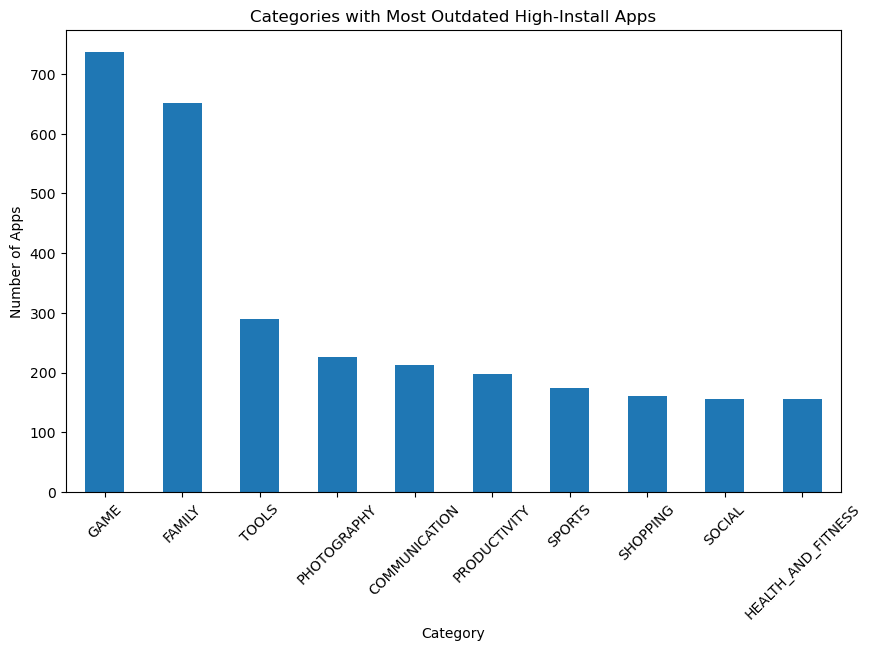

In [209]:
import matplotlib.pyplot as plt

outdated_high_installs = df[
    (df["App_Age"] >= 2) &
    (df["Installs"] >= 1000000)
]

count = (
    outdated_high_installs.groupby("Category")["App"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
count.plot(kind="bar")

plt.title("Categories with Most Outdated High-Install Apps")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)

plt.show()

Do apps that launched earlier (older Last Updated year) show declining ratings over time

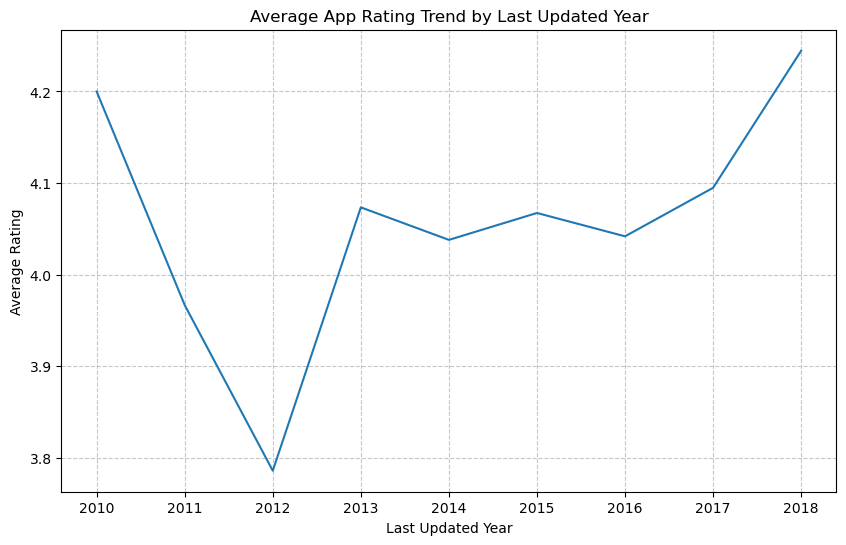

Correlation between App Age and Rating: -0.14


In [213]:
df['Last_Updated_Year'] = pd.to_datetime(df['Last Updated']).dt.year
mean_rating_by_year = df.groupby('Last_Updated_Year')['Rating'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=mean_rating_by_year.index, y=mean_rating_by_year.values)
plt.title('Average App Rating Trend by Last Updated Year')
plt.xlabel('Last Updated Year')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Correlation between App Age and Rating: {df['App_Age'].corr(df['Rating']):.2f}")